# CORe50 New Classes Experiment — Adaptive Consolidation with Intentional Forgetting

**CpE 620 — Spring 2026**

This notebook evaluates the proposed continual-learning method on a seven-task subset of the
CORe50 New Classes scenario using a shared CNN backbone with task-specific heads.

Compared methods:
- Sequential fine-tuning
- Elastic Weight Consolidation (EWC)
- Adaptive consolidation with intentional forgetting

The CORe50 dataset is downloaded through Avalanche when the notebook is run. This portfolio copy
preserves the original experimental logic and saved results while removing installation and
presentation-only cells.


In [ ]:
# ============================================================
# CELL 2 — Imports and reproducibility
# ============================================================
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import transforms
from avalanche.benchmarks.classic import CORe50

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# ============================================================
# CELL 3 — CORe50 root and transforms
# ============================================================
core50_root = "./core50_data"

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

In [ ]:
# ============================================================
# CELL 4 — Load CORe50 benchmark (LIMITED TO 7 TASKS)
# ============================================================
benchmark = CORe50(
    scenario="nc",
    run=0,
    object_lvl=True,
    mini=False,
    train_transform=train_transform,
    eval_transform=eval_transform,
    dataset_root=core50_root
)

# Limit to the first 7 tasks
num_tasks_to_use = 7

train_stream = benchmark.train_stream[:num_tasks_to_use]
test_stream = benchmark.test_stream[:num_tasks_to_use]

print("Number of training experiences (used):", len(train_stream))
print("Number of test experiences (used):", len(test_stream))

Loading labels...
Loading LUP...
Loading labels names...
Files already downloaded and verified
Number of training experiences (used): 7
Number of test experiences (used): 1


In [ ]:
# ============================================================
# CELL 5 — Inspect experiences
# ============================================================
exp_classes = []
for exp in train_stream:
    cls = sorted(list(exp.classes_in_this_experience))
    exp_classes.append(cls)
    print(f"Experience {exp.current_experience}: classes={cls}, num_samples={len(exp.dataset)}")

num_tasks = len(exp_classes)
head_sizes = [len(cls) for cls in exp_classes]

print("num_tasks =", num_tasks)
print("head_sizes =", head_sizes)

Experience 0: classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], num_samples=23980
Experience 1: classes=[10, 11, 12, 13, 14], num_samples=11993
Experience 2: classes=[15, 16, 17, 18, 19], num_samples=11990
Experience 3: classes=[20, 21, 22, 23, 24], num_samples=11993
Experience 4: classes=[25, 26, 27, 28, 29], num_samples=11989
Experience 5: classes=[30, 31, 32, 33, 34], num_samples=11979
Experience 6: classes=[35, 36, 37, 38, 39], num_samples=11990
num_tasks = 7
head_sizes = [10, 5, 5, 5, 5, 5, 5]


In [ ]:
# ============================================================
# CELL 6 — Optional subset for speed
#         Use 1.0 for full data
#         If runtime is long, use 0.5 or 0.3
# ============================================================
subset_fraction = 0.5

def maybe_subset_dataset(dataset, fraction=0.5, seed=42):
    if fraction >= 1.0:
        return dataset

    n = len(dataset)
    k = max(1, int(n * fraction))
    rng = np.random.default_rng(seed)
    idx = rng.choice(np.arange(n), size=k, replace=False)
    idx = sorted(idx.tolist())
    return Subset(dataset, idx)

In [ ]:
# ============================================================
# CELL 7 — Build train/test datasets per task (CORRECTED)
# ============================================================
train_datasets = []
test_datasets = []

# -----------------------------
# Training datasets: one per experience
# -----------------------------
for i, exp in enumerate(train_stream):
    train_datasets.append(
        maybe_subset_dataset(exp.dataset, fraction=subset_fraction, seed=42 + i)
    )

# -----------------------------
# Test datasets:
# Case 1 -> test_stream already has one test experience per task
# Case 2 -> test_stream has only one complete test set
#          then split it manually by task classes
# -----------------------------
if len(test_stream) == num_tasks:
    for i, exp in enumerate(test_stream):
        test_datasets.append(
            maybe_subset_dataset(exp.dataset, fraction=1.0, seed=100 + i)
        )
else:
    print(f"test_stream has {len(test_stream)} experience(s); building per-task test subsets from the complete test set.")

    full_test_dataset = test_stream[0].dataset

    def get_label_from_sample(sample):
        # CORe50 samples are usually (x, y, ...) so label is index 1
        if isinstance(sample, (list, tuple)) and len(sample) >= 2:
            return int(sample[1])
        raise ValueError("Unexpected sample format while extracting labels from test dataset.")

    for i, cls_list in enumerate(exp_classes):
        allowed = set(cls_list)
        indices = [
            idx for idx in range(len(full_test_dataset))
            if get_label_from_sample(full_test_dataset[idx]) in allowed
        ]
        task_subset = Subset(full_test_dataset, indices)
        test_datasets.append(task_subset)

# -----------------------------
# Sanity check
# -----------------------------
print("Number of train task datasets:", len(train_datasets))
print("Number of test task datasets :", len(test_datasets))

for i in range(len(train_datasets)):
    print(f"Task {i}: train={len(train_datasets[i])}, test={len(test_datasets[i])}")

test_stream has 1 experience(s); building per-task test subsets from the complete test set.
Number of train task datasets: 7
Number of test task datasets : 7
Task 0: train=11990, test=8993
Task 1: train=5996, test=4495
Task 2: train=5995, test=4500
Task 3: train=5996, test=4493
Task 4: train=5994, test=4500
Task 5: train=5989, test=4500
Task 6: train=5995, test=4495


In [ ]:
# ============================================================
# CELL 8 — Dataloaders
# ============================================================
batch_size = 64

train_loaders = [
    DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    for ds in train_datasets
]

test_loaders = [
    DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    for ds in test_datasets
]

In [ ]:
# ============================================================
# CELL 9 — Label remapping per experience
# ============================================================
class_maps = []
for cls in exp_classes:
    local_map = {global_label: local_idx for local_idx, global_label in enumerate(cls)}
    class_maps.append(local_map)

def remap_labels(y, task_id):
    mapper = class_maps[task_id]
    y_cpu = y.detach().cpu().tolist()
    local = [mapper[int(label)] for label in y_cpu]
    return torch.tensor(local, dtype=torch.long, device=y.device)

In [ ]:
# ============================================================
# CELL 10 — Batch unpacking helper
# ============================================================
def unpack_batch(batch):
    if isinstance(batch, (list, tuple)) and len(batch) >= 2:
        x = batch[0]
        y = batch[1]
        return x, y
    raise ValueError("Unexpected batch format")

In [ ]:
# ============================================================
# CELL 11 — Backbone and multi-head model
# ============================================================
class CORe50Backbone(nn.Module):
    def __init__(self, feat_dim=512):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x


class MultiHeadCORe50Net(nn.Module):
    def __init__(self, head_sizes, feat_dim=512):
        super().__init__()
        self.backbone = CORe50Backbone(feat_dim=feat_dim)
        self.heads = nn.ModuleList([nn.Linear(feat_dim, h) for h in head_sizes])

    def forward(self, x, task_id):
        feats = self.backbone(x)
        return self.heads[task_id](feats)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
print("Trainable parameters:", count_params(model))

Trainable parameters: 2611560


In [ ]:
# ============================================================
# CELL 12 — Evaluation utilities
# ============================================================
@torch.no_grad()
def evaluate_task(model, loader, task_id):
    model.eval()
    total, correct = 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)

        y_t = remap_labels(y, task_id)
        logits = model(x, task_id)
        pred = logits.argmax(dim=1)

        total += y_t.size(0)
        correct += (pred == y_t).sum().item()

    return correct / total


def evaluate_seen_tasks(model, seen_tasks):
    return [evaluate_task(model, test_loaders[t], t) for t in seen_tasks]


def print_seen_task_summary(model, seen_tasks, note=""):
    accs = evaluate_seen_tasks(model, seen_tasks)
    mean_acc = np.mean(accs) if len(accs) > 0 else 0.0
    print(
        f"{note} | " +
        ", ".join([f"T{t}:{accs[i]:.4f}" for i, t in enumerate(seen_tasks)]) +
        f" | Mean:{mean_acc:.4f}"
    )
    return accs, mean_acc

In [ ]:
# ============================================================
# CELL 13 — Training helpers
# ============================================================
def set_trainable(model, train_backbone=True, train_heads=None):
    for p in model.backbone.parameters():
        p.requires_grad = train_backbone

    if train_heads is None:
        for head in model.heads:
            for p in head.parameters():
                p.requires_grad = True
    else:
        for i, head in enumerate(model.heads):
            flag = i in train_heads
            for p in head.parameters():
                p.requires_grad = flag


def get_optimizer(model, lr=1e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)


def train_one_epoch(model, loader, optimizer, task_id, extra_loss_fn=None):
    model.train()
    total_loss = 0.0
    total = 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)
        y_t = remap_labels(y, task_id)

        optimizer.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)

        if extra_loss_fn is not None:
            loss = loss + extra_loss_fn(model)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_t.size(0)
        total += y_t.size(0)

    return total_loss / total

In [ ]:
# ============================================================
# CELL 14 — Forgetting metric
# ============================================================
def compute_forgetting(acc_matrix):
    forgetting_per_task = {}
    final_row = acc_matrix[-1]

    for task_j in range(len(final_row)):
        prev = [acc_matrix[i][task_j] for i in range(len(acc_matrix)) if acc_matrix[i][task_j] is not None]
        if len(prev) == 0:
            continue
        best_before_final = max(prev[:-1]) if len(prev) > 1 else prev[0]
        final_acc = final_row[task_j]
        forgetting_per_task[task_j] = best_before_final - final_acc

    mean_forgetting = np.mean(list(forgetting_per_task.values()))
    return forgetting_per_task, mean_forgetting


def final_avg_accuracy(acc_matrix):
    return np.mean([x for x in acc_matrix[-1] if x is not None])

In [ ]:
# ============================================================
# CELL 15 — EWC helpers
# ============================================================
def snapshot_backbone(model):
    return {n: p.detach().clone() for n, p in model.backbone.named_parameters()}

def compute_fisher_diag_backbone(model, data_loader, task_id, num_batches=100):
    model.eval()

    fisher = {
        n: torch.zeros_like(p, device=device)
        for n, p in model.backbone.named_parameters()
    }

    count = 0
    for batch in data_loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)
        y_t = remap_labels(y, task_id)

        model.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)
        loss.backward()

        for n, p in model.backbone.named_parameters():
            if p.grad is not None:
                fisher[n] += (p.grad.detach() ** 2)

        count += 1
        if count >= num_batches:
            break

    for n in fisher:
        fisher[n] /= max(count, 1)

    return fisher


class EWCBackbone:
    def __init__(self, fisher, theta_old, lam=500.0):
        self.fisher = fisher
        self.theta_old = theta_old
        self.lam = lam

    def penalty(self, model):
        loss = 0.0
        for n, p in model.backbone.named_parameters():
            loss += (self.fisher[n] * (p - self.theta_old[n]) ** 2).sum()
        return self.lam * loss


def add_fishers(fisher_a, fisher_b):
    if fisher_a is None:
        return {k: v.clone() for k, v in fisher_b.items()}
    return {k: fisher_a[k] + fisher_b[k] for k in fisher_a}

def average_fisher(fisher, divisor):
    return {k: fisher[k] / divisor for k in fisher}

In [ ]:
# ============================================================
# CELL 16 — Intentional forgetting
# ============================================================
@torch.no_grad()
def targeted_forgetting_backbone(model, fisher, forget_rate=1e-4, percentile=10):
    for n, p in model.backbone.named_parameters():
        Fval = fisher[n]
        thresh = torch.quantile(Fval.view(-1), percentile / 100.0)
        low_mask = (Fval <= thresh)
        p[low_mask] *= (1.0 - forget_rate)

In [ ]:
# ============================================================
# CELL 17 — Sequential Fine-Tuning
# ============================================================
def run_sequential_finetuning(epochs_per_task=5):
    model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
    acc_matrix = []
    mean_history = []

    print("\n========== SEQUENTIAL FINE-TUNING ON CORe50 ==========")

    for current_task in range(num_tasks):
        print(f"\n--- Training Sequential on Task {current_task} ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task)
            _, mean_acc = print_seen_task_summary(
                model,
                list(range(current_task + 1)),
                note=f"Sequential T{current_task} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 18 — EWC
# ============================================================
def run_ewc(epochs_per_task=5, lam=500.0):
    model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
    acc_matrix = []
    mean_history = []

    consolidated_fisher = None
    task_snapshots = []
    num_consolidated_tasks = 0

    print("\n========== EWC ON CORe50 ==========")

    for current_task in range(num_tasks):
        print(f"\n--- Training EWC on Task {current_task} ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        if current_task == 0:
            extra_loss_fn = None
        else:
            avg_fisher = average_fisher(consolidated_fisher, num_consolidated_tasks)
            theta_old = task_snapshots[-1]
            ewc = EWCBackbone(avg_fisher, theta_old, lam=lam)
            extra_loss_fn = ewc.penalty

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task, extra_loss_fn=extra_loss_fn)
            _, mean_acc = print_seen_task_summary(
                model,
                list(range(current_task + 1)),
                note=f"EWC T{current_task} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

        fisher_t = compute_fisher_diag_backbone(model, train_loaders[current_task], current_task, num_batches=100)
        consolidated_fisher = add_fishers(consolidated_fisher, fisher_t)
        task_snapshots.append(snapshot_backbone(model))
        num_consolidated_tasks += 1

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 19 — Proposed Method: Adaptive Consolidation + Intentional Forgetting
# ============================================================
def run_proposed(epochs_per_task=5, lam=700.0, forget_rate=1e-4, percentile=10):
    model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
    acc_matrix = []
    mean_history = []

    consolidated_fisher = None
    task_snapshots = []
    num_consolidated_tasks = 0

    print("\n========== PROPOSED METHOD ON CORe50 ==========")

    for current_task in range(num_tasks):
        print(f"\n--- Training Proposed Method on Task {current_task} ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        if current_task == 0:
            extra_loss_fn = None
            avg_fisher = None
        else:
            avg_fisher = average_fisher(consolidated_fisher, num_consolidated_tasks)
            theta_old = task_snapshots[-1]
            ewc = EWCBackbone(avg_fisher, theta_old, lam=lam)
            extra_loss_fn = ewc.penalty

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task, extra_loss_fn=extra_loss_fn)

            if current_task > 0:
                targeted_forgetting_backbone(
                    model,
                    avg_fisher,
                    forget_rate=forget_rate,
                    percentile=percentile
                )

            _, mean_acc = print_seen_task_summary(
                model,
                list(range(current_task + 1)),
                note=f"Proposed T{current_task} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

        fisher_t = compute_fisher_diag_backbone(model, train_loaders[current_task], current_task, num_batches=100)
        consolidated_fisher = add_fishers(consolidated_fisher, fisher_t)
        task_snapshots.append(snapshot_backbone(model))
        num_consolidated_tasks += 1

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 20 — Run all methods
# ============================================================
epochs_per_task = 5
lam = 500.0
forget_rate = 1e-4

seq_model, seq_acc_matrix, seq_mean_hist = run_sequential_finetuning(epochs_per_task=epochs_per_task)
ewc_model, ewc_acc_matrix, ewc_mean_hist = run_ewc(epochs_per_task=epochs_per_task, lam=lam)
prop_model, prop_acc_matrix, prop_mean_hist = run_proposed(
    epochs_per_task=epochs_per_task,
    lam=lam,
    forget_rate=forget_rate,
    percentile=10
)


========== SEQUENTIAL FINE-TUNING ON CORe50 ==========

--- Training Sequential on Task 0 ---
Sequential T0 Ep1 | loss=1.0131 | T0:0.4290 | Mean:0.4290
Sequential T0 Ep2 | loss=0.4185 | T0:0.3730 | Mean:0.3730
Sequential T0 Ep3 | loss=0.2724 | T0:0.5120 | Mean:0.5120
Sequential T0 Ep4 | loss=0.2162 | T0:0.5871 | Mean:0.5871
Sequential T0 Ep5 | loss=0.1577 | T0:0.6143 | Mean:0.6143

--- Training Sequential on Task 1 ---
Sequential T1 Ep1 | loss=0.1788 | T0:0.1521, T1:0.6937 | Mean:0.4229
Sequential T1 Ep2 | loss=0.0506 | T0:0.2389, T1:0.7112 | Mean:0.4750
Sequential T1 Ep3 | loss=0.0679 | T0:0.1815, T1:0.7326 | Mean:0.4570
Sequential T1 Ep4 | loss=0.0504 | T0:0.1337, T1:0.7740 | Mean:0.4538
Sequential T1 Ep5 | loss=0.0274 | T0:0.1235, T1:0.7290 | Mean:0.4263

--- Training Sequential on Task 2 ---
Sequential T2 Ep1 | loss=0.5690 | T0:0.2193, T1:0.4412, T2:0.5424 | Mean:0.4010
Sequential T2 Ep2 | loss=0.2196 | T0:0.1843, T1:0.4202, T2:0.5611 | Mean:0.3885
Sequential T2 Ep3 | loss=0.1428 

In [ ]:
# ============================================================
# CELL 21 — Final metrics
# ============================================================
seq_final_acc = final_avg_accuracy(seq_acc_matrix)
ewc_final_acc = final_avg_accuracy(ewc_acc_matrix)
prop_final_acc = final_avg_accuracy(prop_acc_matrix)

seq_forgetting_per_task, seq_mean_forgetting = compute_forgetting(seq_acc_matrix)
ewc_forgetting_per_task, ewc_mean_forgetting = compute_forgetting(ewc_acc_matrix)
prop_forgetting_per_task, prop_mean_forgetting = compute_forgetting(prop_acc_matrix)

print("Sequential Final Avg Accuracy:", seq_final_acc)
print("EWC Final Avg Accuracy       :", ewc_final_acc)
print("Proposed Final Avg Accuracy  :", prop_final_acc)

print("\nSequential Mean Forgetting:", seq_mean_forgetting)
print("EWC Mean Forgetting       :", ewc_mean_forgetting)
print("Proposed Mean Forgetting  :", prop_mean_forgetting)

Sequential Final Avg Accuracy: 0.2833229439294855
EWC Final Avg Accuracy       : 0.3467133138911249
Proposed Final Avg Accuracy  : 0.47467937192556114

Sequential Mean Forgetting: 0.361469285443479
EWC Mean Forgetting       : 0.2918788791482894
Proposed Mean Forgetting  : 0.12396283438923542


In [ ]:
# ============================================================
# CELL 22 — Results dictionary
# ============================================================
results = {
    "Sequential Fine-Tuning": {
        "Final Avg Accuracy": seq_final_acc,
        "Mean Forgetting": seq_mean_forgetting
    },
    "EWC": {
        "Final Avg Accuracy": ewc_final_acc,
        "Mean Forgetting": ewc_mean_forgetting
    },
    "Adaptive Consolidation + Intentional Forgetting": {
        "Final Avg Accuracy": prop_final_acc,
        "Mean Forgetting": prop_mean_forgetting
    }
}
results

{'Sequential Fine-Tuning': {'Final Avg Accuracy': np.float64(0.2833229439294855),
  'Mean Forgetting': np.float64(0.361469285443479)},
 'EWC': {'Final Avg Accuracy': np.float64(0.3467133138911249),
  'Mean Forgetting': np.float64(0.2918788791482894)},
 'Adaptive Consolidation + Intentional Forgetting': {'Final Avg Accuracy': np.float64(0.47467937192556114),
  'Mean Forgetting': np.float64(0.12396283438923542)}}

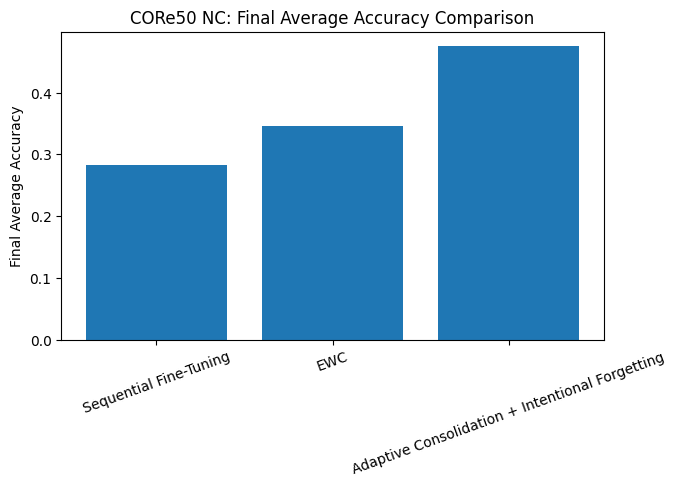

In [ ]:
# ============================================================
# CELL 23 — Plot final average accuracy
# ============================================================
labels = list(results.keys())
vals = [results[k]["Final Avg Accuracy"] for k in labels]

plt.figure(figsize=(7,4))
plt.bar(labels, vals)
plt.ylabel("Final Average Accuracy")
plt.title("CORe50 NC: Final Average Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

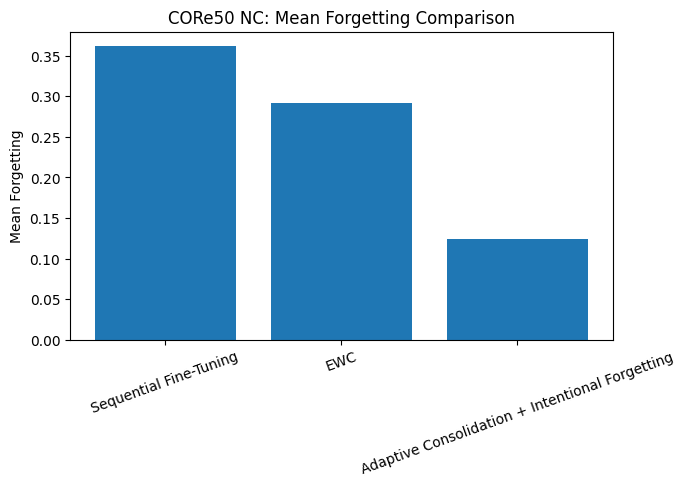

In [ ]:
# ============================================================
# CELL 24 — Plot mean forgetting
# ============================================================
labels = list(results.keys())
vals = [results[k]["Mean Forgetting"] for k in labels]

plt.figure(figsize=(7,4))
plt.bar(labels, vals)
plt.ylabel("Mean Forgetting")
plt.title("CORe50 NC: Mean Forgetting Comparison")
plt.xticks(rotation=20)
plt.show()

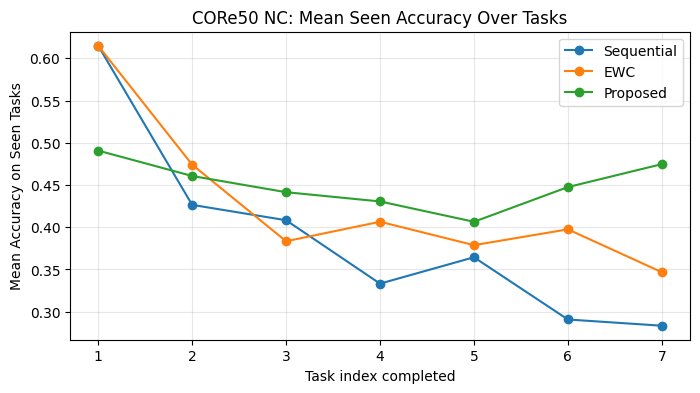

In [ ]:
# ============================================================
# CELL 25 — Plot mean seen accuracy trajectory
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(range(1, num_tasks + 1), seq_mean_hist, marker="o", label="Sequential")
plt.plot(range(1, num_tasks + 1), ewc_mean_hist, marker="o", label="EWC")
plt.plot(range(1, num_tasks + 1), prop_mean_hist, marker="o", label="Proposed")

plt.xlabel("Task index completed")
plt.ylabel("Mean Accuracy on Seen Tasks")
plt.title("CORe50 NC: Mean Seen Accuracy Over Tasks")
plt.xticks(range(1, num_tasks + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# CELL 26 — Per-task forgetting printout
# ============================================================
print("Sequential forgetting per task:")
for k, v in seq_forgetting_per_task.items():
    print(f"Task {k}: {v:.4f}")

print("\nEWC forgetting per task:")
for k, v in ewc_forgetting_per_task.items():
    print(f"Task {k}: {v:.4f}")

print("\nProposed forgetting per task:")
for k, v in prop_forgetting_per_task.items():
    print(f"Task {k}: {v:.4f}")

Sequential forgetting per task:
Task 0: 0.5296
Task 1: 0.5028
Task 2: 0.4104
Task 3: 0.3450
Task 4: 0.4702
Task 5: 0.2722
Task 6: 0.0000

EWC forgetting per task:
Task 0: 0.4965
Task 1: 0.5341
Task 2: 0.2164
Task 3: 0.3252
Task 4: 0.2016
Task 5: 0.2693
Task 6: 0.0000

Proposed forgetting per task:
Task 0: 0.0755
Task 1: 0.1855
Task 2: 0.0040
Task 3: 0.1625
Task 4: 0.2364
Task 5: 0.2038
Task 6: 0.0000
